In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
eps = np.loadtxt('./all_stats_eps.txt')
all_data = np.loadtxt('./all_stats.txt')


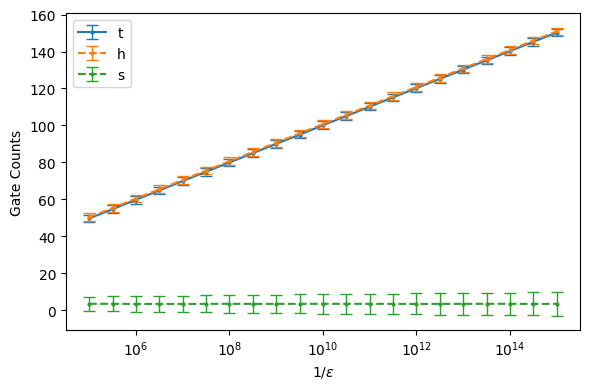

In [3]:
plt.figure(figsize=(6, 4))

plt.errorbar(1/eps, all_data[:,0],
    yerr=all_data[:,1],
    fmt='o-',
    capsize=4,
    elinewidth=1,
    markersize=2,
    label='t'
)

plt.errorbar(1/eps, all_data[:,2],
    yerr=all_data[:,3],
    fmt='o--',
    capsize=4,
    elinewidth=1,
    markersize=2,
    label='h'
)

plt.errorbar(1/eps, all_data[:,4],
    yerr=all_data[:,5],
    fmt='o--',
    capsize=4,
    elinewidth=1,
    markersize=2,
    label='s'
)

plt.xscale('log')  # since eps spans 1e-5 to 1e-15
plt.xlabel(r'$1/\epsilon$')
plt.ylabel('Gate Counts')
plt.legend(loc=0)

plt.tight_layout()
plt.show()

In [4]:
coeff = np.polyfit(np.log10(1/eps), all_data[:,0], 1)   # degree 1 polynomial
a, b = coeff
print(f'slop: {a}, intercept: {b}')

slop: 10.051041038961037, intercept: -0.4648484848484043


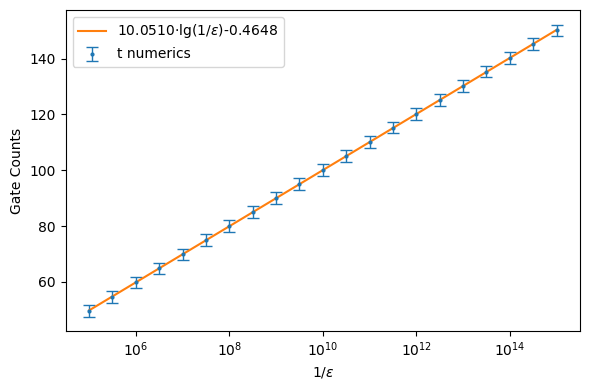

In [5]:
fit_data = a * np.log10(1/eps) + b
plt.figure(figsize=(6, 4))

plt.errorbar(1/eps, all_data[:,0],
    yerr=all_data[:,1],
    fmt='o',
    capsize=4,
    elinewidth=1,
    markersize=2,
    label='t numerics'
)

plt.plot(1/eps, fit_data, label=rf'{a:.4f}$\cdot \lg(1/\epsilon)${b:.4f}')

plt.xscale('log')  # since eps spans 1e-5 to 1e-15
plt.xlabel(r'$1/\epsilon$')
plt.ylabel('Gate Counts')
plt.legend(loc=0)

plt.tight_layout()
plt.show()